<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Duplicates Lab**


Estimated time needed: **30** minutes


## Introduction


Data wrangling is a critical step in preparing datasets for analysis, and handling duplicates plays a key role in ensuring data accuracy. In this lab, you will focus on identifying and removing duplicate entries from your dataset. 


## Objectives


In this lab, you will perform the following:


1. Identify duplicate rows in the dataset and analyze their characteristics.
2. Visualize the distribution of duplicates based on key attributes.
3. Remove duplicate values strategically based on specific criteria.
4. Outline the process of verifying and documenting duplicate removal.


## Hands on Lab


Install the needed library


In [1]:
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 183.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 172.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 160.0 MB/s eta 0:00:00


Import pandas module


In [2]:
import pandas as pd


Import matplotlib


In [3]:
import matplotlib.pyplot as plt


## **Load the dataset into a dataframe**


<h2>Read Data</h2>
<p>
We utilize the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


In [4]:
# Load the dataset directly from the URL
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/VYPrOu0Vs3I0hKLLjiPGrA/survey-data-with-duplicate.csv"
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

Load the data into a pandas dataframe:



Note: If you are working on a local Jupyter environment, you can use the URL directly in the pandas.read_csv() function as shown below:



In [ ]:
# df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


## Identify and Analyze Duplicates


### Task 1: Identify Duplicate Rows
1. Count the number of duplicate rows in the dataset.
3. Display the first few duplicate rows to understand their structure.


In [5]:
## Write your code here
num_dup = df.duplicated().sum()
print(f"Number of duplicated rows: {num_dup}")

Number of duplicated rows: 20


In [7]:
dup_rows = df[df.duplicated()]
print(dup_rows)

       ResponseId                                         MainBranch  \
65437           1                     I am a developer by profession   
65438           2                     I am a developer by profession   
65439           3                     I am a developer by profession   
65440           4                              I am learning to code   
65441           5                     I am a developer by profession   
65442           6                        I code primarily as a hobby   
65443           7  I am not primarily a developer, but I write co...   
65444           8                              I am learning to code   
65445           9                        I code primarily as a hobby   
65446          10                     I am a developer by profession   
65447       18522                     I am a developer by profession   
65448       49767                        I code primarily as a hobby   
65449       51198                     I am a developer by profes

### Task 2: Analyze Characteristics of Duplicates
1. Identify duplicate rows based on selected columns such as MainBranch, Employment, and RemoteWork. Analyse which columns frequently contain identical values within these duplicate rows.
2. Analyse the characteristics of rows that are duplicates based on a subset of columns, such as MainBranch, Employment, and RemoteWork. Determine which columns frequently have identical values across these rows.
   


In [8]:
## Write your code here
cols_to_check = ['MainBranch', 'Employment', 'RemoteWork']
dup_df = df[df.duplicated(subset=cols_to_check, keep=False)]
print(f"Found {len(dup_df)} rows that share identical values in {cols_to_check}")
print(dup_df[cols_to_check].head())

Found 65290 rows that share identical values in ['MainBranch', 'Employment', 'RemoteWork']
                       MainBranch           Employment RemoteWork
0  I am a developer by profession  Employed, full-time     Remote
1  I am a developer by profession  Employed, full-time     Remote
2  I am a developer by profession  Employed, full-time     Remote
3           I am learning to code   Student, full-time        NaN
4  I am a developer by profession   Student, full-time        NaN


In [10]:
top_duplicate_combinations = dup_df[cols_to_check].value_counts().reset_index()
top_duplicate_combinations.columns = ['MainBranch', 'Employment', 'RemoteWork', 'Frequency']

print("Most frequent identical combinations in duplicate rows:")
print(top_duplicate_combinations.head(10))

Most frequent identical combinations in duplicate rows:
                                          MainBranch  \
0                     I am a developer by profession   
1                     I am a developer by profession   
2                     I am a developer by profession   
3                     I am a developer by profession   
4                     I am a developer by profession   
5  I am not primarily a developer, but I write co...   
6                     I am a developer by profession   
7                     I am a developer by profession   
8  I am not primarily a developer, but I write co...   
9  I am not primarily a developer, but I write co...   

                                          Employment  \
0                                Employed, full-time   
1                                Employed, full-time   
2                                Employed, full-time   
3  Independent contractor, freelancer, or self-em...   
4  Employed, full-time;Independent contractor, 

In [12]:
for col in cols_to_check:
    print(f"\nFrequency of values in '{col}' among duplicates:")
    print(dup_df[col].value_counts().head(5))


Frequency of values in 'MainBranch' among duplicates:
MainBranch
I am a developer by profession                                                           50173
I am not primarily a developer, but I write code sometimes as part of my work/studies     6471
I am learning to code                                                                     3847
I code primarily as a hobby                                                               3317
I used to be a developer by profession, but no longer am                                  1482
Name: count, dtype: int64

Frequency of values in 'Employment' among duplicates:
Employment
Employed, full-time                                                         39048
Independent contractor, freelancer, or self-employed                         4845
Student, full-time                                                           4713
Employed, full-time;Independent contractor, freelancer, or self-employed     3558
Not employed, but looking for work     

### Task 3: Visualize Duplicates Distribution
1. Create visualizations to show the distribution of duplicates across different categories.
2. Use bar charts or pie charts to represent the distribution of duplicates by Country and Employment.


In [20]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [21]:
import seaborn as sns

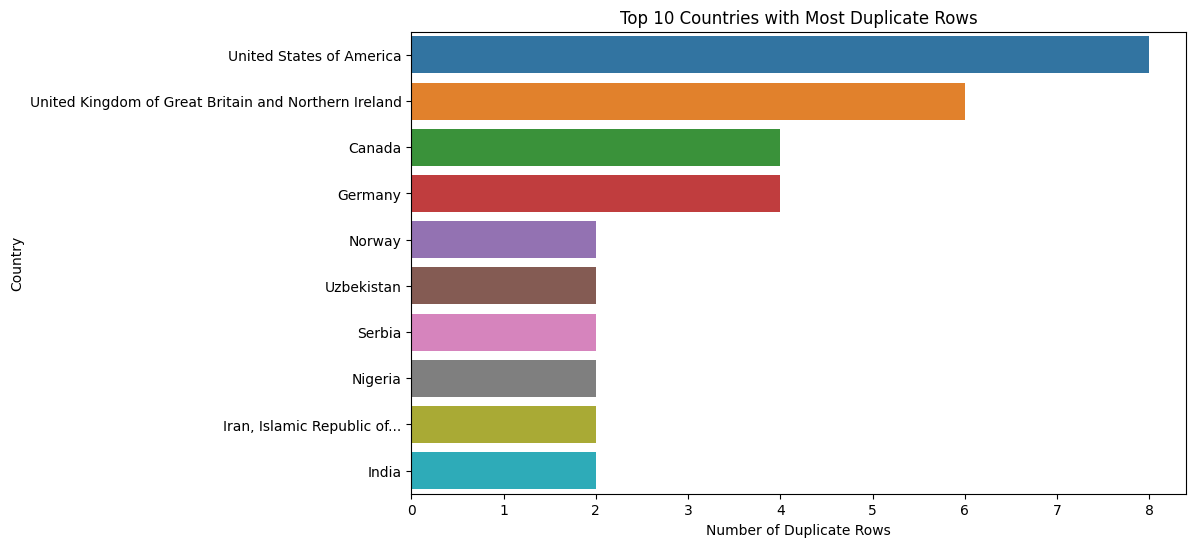

In [23]:
## Write your code here
duplicates_df = df[df.duplicated(keep=False)]
plt.figure(figsize=(10, 6))
# Get Top 10 countries with most duplicates
top_countries = duplicates_df['Country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index)
plt.title('Top 10 Countries with Most Duplicate Rows')
plt.xlabel('Number of Duplicate Rows')
plt.ylabel('Country')
plt.show()

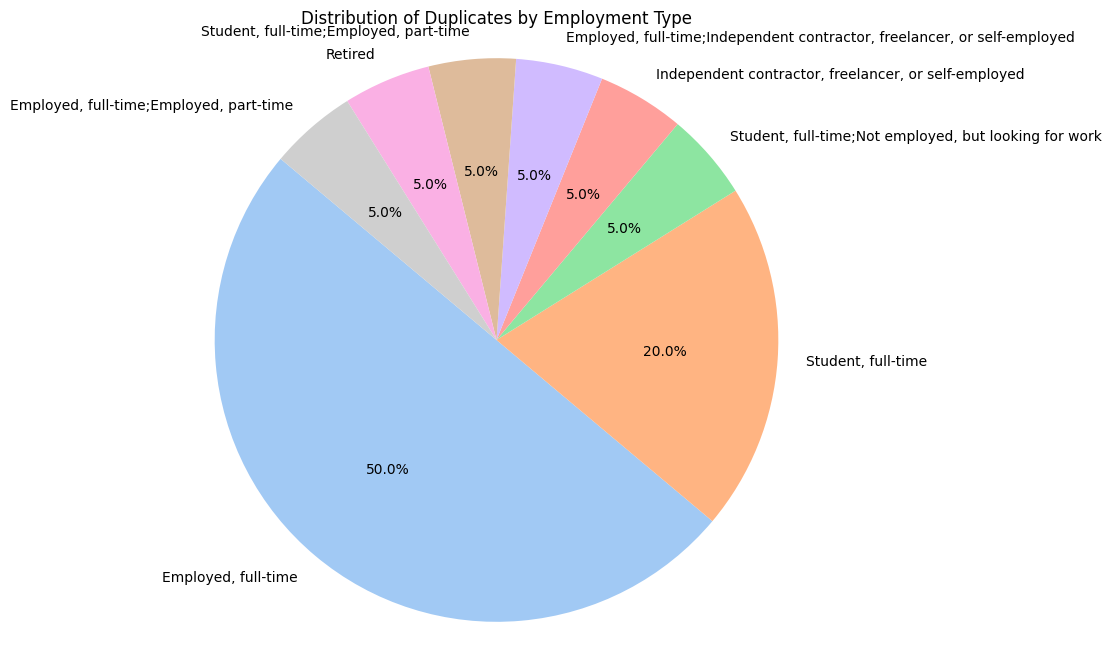

In [24]:
plt.figure(figsize=(8, 8))
employment_counts = duplicates_df['Employment'].value_counts()

# Create a pie chart
plt.pie(employment_counts, labels=employment_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Duplicates by Employment Type')
plt.axis('equal') 
plt.show()

### Task 4: Strategic Removal of Duplicates
1. Decide which columns are critical for defining uniqueness in the dataset.
2. Remove duplicates based on a subset of columns if complete row duplication is not a good criterion.


In [25]:
## Write your code here
critical_cols = ['Country', 'Age', 'Employment', 'MainBranch', 'RemoteWork']
duplicates_count = df.duplicated(subset=critical_cols).sum()
print(f"Rows to be removed based on {critical_cols}: {duplicates_count}")

Rows to be removed based on ['Country', 'Age', 'Employment', 'MainBranch', 'RemoteWork']: 53316


In [26]:
# Remove duplicates, keeping only the first occurrence
df_cleaned = df.drop_duplicates(subset=critical_cols, keep='first')

print(f"Original row count: {len(df)}")
print(f"Cleaned row count: {len(df_cleaned)}")

Original row count: 65457
Cleaned row count: 12141


In [27]:
df_cleaned.to_csv('survey_data_cleaned.csv', index=False)

## Verify and Document Duplicate Removal Process


### Task 5: Documentation
1. Document the process of identifying and removing duplicates.


2. Explain the reasoning behind selecting specific columns for identifying and removing duplicates.


### Summary and Next Steps
**In this lab, you focused on identifying and analyzing duplicate rows within the dataset.**

- You employed various techniques to explore the nature of duplicates and applied strategic methods for their removal.
- For additional analysis, consider investigating the impact of duplicates on specific analyses and how their removal affects the results.
- This version of the lab is more focused on duplicate analysis and handling, providing a structured approach to deal with duplicates in a dataset effectively.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11- 05|1.3|Madhusudhan Moole|Updated lab|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
